In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib_inline.backend_inline import set_matplotlib_formats
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import patheffects as pe

import sys
from pathlib import Path
import os

# Add the src directory to Python path
script_dir = Path.cwd()
quantitative_dir = script_dir.parent
src_path = quantitative_dir / 'src'
sys.path.insert(0, str(src_path))

# Change to quantitative directory for proper file paths
os.chdir(quantitative_dir)

# Now import and use the dataloader
from dataloader import load_paper_df
from dataloader import load_most_recent_df
from pareto_utils import compute_pareto_frontier_with_origin, _pareto_indices, compute_pareto_statistics, compute_model_pareto_rankings
from plotting_utils import setup_colors, get_scaffold_hatch, setup_plot_style

In [2]:
model_df, agent_df, benchmark_df = load_paper_df()

In [3]:
# remove where model contains Sonnet 4
model_df = model_df[~model_df['model'].str.contains('Sonnet 4', na=False)]
benchmark_df = benchmark_df[~benchmark_df['model'].str.contains('Sonnet 4', na=False)]

In [4]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def distance_to_convex_hull(point, hull_vertices):
    """
    Compute the minimum distance from a point to a convex hull.
    
    Args:
        point: Array-like [x, y] representing the point
        hull_vertices: Array of shape (n, 2) representing convex hull vertices
        
    Returns:
        float: Minimum distance from point to the convex hull
    """
    point = np.array(point)
    hull = np.array(hull_vertices)
    
    if len(hull) == 0:
        return np.inf
    
    # If only one point in hull, return distance to that point
    if len(hull) == 1:
        return np.linalg.norm(point - hull[0])
    
    min_distance = np.inf
    
    # Check distance to each edge of the convex hull
    for i in range(len(hull)):
        # Get edge from vertex i to vertex i+1 (wrapping around)
        v1 = hull[i]
        v2 = hull[(i + 1) % len(hull)]
        
        # Vector from v1 to v2
        edge = v2 - v1
        edge_length_sq = np.dot(edge, edge)
        
        # Handle degenerate case (edge has zero length)
        if edge_length_sq < 1e-10:
            dist = np.linalg.norm(point - v1)
            min_distance = min(min_distance, dist)
            continue
        
        # Parameter t for projection of point onto the line containing the edge
        # t = 0 corresponds to v1, t = 1 corresponds to v2
        t = np.dot(point - v1, edge) / edge_length_sq
        
        if t < 0:
            # Closest point is v1
            closest_point = v1
        elif t > 1:
            # Closest point is v2
            closest_point = v2
        else:
            # Closest point is on the edge between v1 and v2
            closest_point = v1 + t * edge
        
        # Compute distance to closest point on this edge
        dist = np.linalg.norm(point - closest_point)
        min_distance = min(min_distance, dist)
    
    return min_distance

In [5]:
def normalize_benchmark_data(sub_df, cost_col='total_cost', acc_col='accuracy'):
    """
    Normalize cost and accuracy columns to [0, 1] range for a single benchmark.
    
    Args:
        sub_df: DataFrame containing data for a single benchmark
        cost_col: Name of the cost column to normalize
        acc_col: Name of the accuracy column to normalize
        
    Returns:
        DataFrame with added 'norm_cost' and 'norm_accuracy' columns
    """
    df = sub_df.copy()
    
    # Extract cost and accuracy values
    costs = df[cost_col].values.reshape(-1, 1)
    accs = df[acc_col].values.reshape(-1, 1)
    
    # Initialize scalers
    cost_scaler = MinMaxScaler()
    acc_scaler = MinMaxScaler()
    
    # Fit and transform
    # Handle case where all values are the same
    if costs.min() == costs.max():
        df['norm_cost'] = 0.5  # Center at 0.5 if all costs are identical
    else:
        df['norm_cost'] = cost_scaler.fit_transform(costs).flatten()
    
    if accs.min() == accs.max():
        df['norm_accuracy'] = 0.5  # Center at 0.5 if all accuracies are identical
    else:
        df['norm_accuracy'] = acc_scaler.fit_transform(accs).flatten()
    
    return df

In [6]:
def compute_frontier_distances(df, cost_col='total_cost', acc_col='accuracy', use_log_cost=False):
    """
    Compute normalized distances from each model to the Pareto frontier for each benchmark.
    
    IMPORTANT: Pareto frontier is computed on RAW (or log-transformed) data to match existing analysis,
    then both the frontier and data points are normalized for distance calculation.
    
    Args:
        df: DataFrame containing benchmark data with columns:
            - benchmark_name: Name of benchmark
            - model: Model name
            - {cost_col}: Cost values
            - {acc_col}: Accuracy values
        cost_col: Name of the cost column (default: 'total_cost')
        acc_col: Name of the accuracy column (default: 'accuracy')
        use_log_cost: If True, compute frontier and distances using log10(cost)
                      This treats cost multiplicatively rather than additively.
                      Default: False (use linear cost)
        
    Returns:
        DataFrame with columns:
            - benchmark_name: Name of benchmark
            - model: Model name
            - normalized_distance: Distance to frontier in normalized [0,1]² space
            - is_on_pareto: Boolean indicating if model is on the Pareto frontier
            - norm_cost: Normalized cost value (log-transformed if use_log_cost=True)
            - norm_accuracy: Normalized accuracy value
            - cost_metric: 'linear' or 'log' indicating which cost metric was used
    """
    required_cols = ["benchmark_name", "model", cost_col, acc_col]
    
    # Validate required columns exist
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    # Aggregate to model × benchmark means (matching existing analysis)
    plot_df = (
        df.dropna(subset=required_cols)
          .groupby(["benchmark_name", "model"], as_index=False)
          .agg({cost_col: "mean", acc_col: "mean"})
    )
    
    results = []
    cost_metric = 'log' if use_log_cost else 'linear'
    
    # Process each benchmark separately
    for bench in sorted(plot_df['benchmark_name'].unique()):
        sub = plot_df[plot_df['benchmark_name'] == bench].copy()
        
        if sub.empty:
            continue
        
        # Extract RAW values
        raw_costs = sub[cost_col].to_numpy()
        raw_accs = sub[acc_col].to_numpy()
        
        # Apply log transformation if requested
        if use_log_cost:
            # Add small epsilon to avoid log(0)
            epsilon = 1e-10
            costs_for_frontier = np.log10(raw_costs + epsilon)
        else:
            costs_for_frontier = raw_costs
        
        # Step 1: Compute Pareto frontier on transformed data
        raw_pareto_frontier = compute_pareto_frontier_with_origin(costs_for_frontier, raw_accs)
        
        # Step 2: Identify which models are on the Pareto frontier
        # Add origin to the data for comparison (matching existing approach)
        costs_with_origin = np.concatenate([[0], costs_for_frontier])
        accs_with_origin = np.concatenate([[0], raw_accs])
        p_idx_with_origin = _pareto_indices(costs_with_origin, accs_with_origin)
        
        # Filter out origin (index 0) and adjust indices back to original data
        pareto_model_indices = [idx - 1 for idx in p_idx_with_origin if idx > 0]
        pareto_model_set = set(sub.iloc[pareto_model_indices]['model'].tolist())
        
        # Step 3: Normalize the data for distance calculation
        # Create a temporary dataframe with transformed costs
        sub_for_norm = sub.copy()
        sub_for_norm[cost_col] = costs_for_frontier
        sub_norm = normalize_benchmark_data(sub_for_norm, cost_col=cost_col, acc_col=acc_col)
        
        # Step 4: Normalize the Pareto frontier using the same scaling
        # Extract the min/max from the transformed data to apply same normalization to frontier
        cost_min, cost_max = costs_for_frontier.min(), costs_for_frontier.max()
        acc_min, acc_max = raw_accs.min(), raw_accs.max()
        
        # Normalize frontier points
        if cost_max > cost_min:
            norm_frontier_x = (raw_pareto_frontier[:, 0] - cost_min) / (cost_max - cost_min)
        else:
            norm_frontier_x = np.full(len(raw_pareto_frontier), 0.5)
            
        if acc_max > acc_min:
            norm_frontier_y = (raw_pareto_frontier[:, 1] - acc_min) / (acc_max - acc_min)
        else:
            norm_frontier_y = np.full(len(raw_pareto_frontier), 0.5)
            
        norm_pareto_frontier = np.column_stack([norm_frontier_x, norm_frontier_y])
        
        # Step 5: Compute distance for each model
        for idx, row in sub_norm.iterrows():
            model_name = row['model']
            norm_point = np.array([row['norm_cost'], row['norm_accuracy']])
            
            # Check if model is on Pareto frontier
            is_on_pareto = model_name in pareto_model_set
            
            # Compute distance to convex hull
            if is_on_pareto:
                # If on frontier, distance is 0
                distance = 0.0
            else:
                # Compute distance to the normalized convex hull
                distance = distance_to_convex_hull(norm_point, norm_pareto_frontier)
            
            results.append({
                'benchmark_name': bench,
                'model': model_name,
                'normalized_distance': distance,
                'is_on_pareto': is_on_pareto,
                'norm_cost': row['norm_cost'],
                'norm_accuracy': row['norm_accuracy'],
                'cost_metric': cost_metric
            })
    
    return pd.DataFrame(results)

In [7]:
def compute_accuracy_weighted_distances(df, cost_col='total_cost', acc_col='accuracy', 
                                       weighting_method='utility_score', epsilon=0.01, use_log_cost=True):
    """
    Compute accuracy-weighted distances from each model to the Pareto frontier for each benchmark.
    
    This addresses the issue where low-cost, low-accuracy models have small distances to the
    origin-based frontier despite being practically useless.
    
    Args:
        df: DataFrame containing benchmark data with columns:
            - benchmark_name: Name of benchmark
            - model: Model name
            - {cost_col}: Cost values
            - {acc_col}: Accuracy values
        cost_col: Name of the cost column (default: 'total_cost')
        acc_col: Name of the accuracy column (default: 'accuracy')
        weighting_method: How to weight by accuracy (default: 'utility_score')
            - 'inverse': weighted_distance = raw_distance / (accuracy + epsilon)
                        Lower is better. Penalizes low accuracy heavily.
            - 'utility_score': score = accuracy / (1 + raw_distance)
                              Higher is better. Balances accuracy and distance.
            - 'penalty': weighted_distance = raw_distance * (1 - accuracy)
                        Lower is better. Multiplicative penalty for low accuracy.
        epsilon: Small value to avoid division by zero (default: 0.01)
        use_log_cost: If True, compute frontier and distances using log10(cost)
                      This treats cost multiplicatively rather than additively.
                      Default: False (use linear cost)
        
    Returns:
        DataFrame with columns:
            - benchmark_name: Name of benchmark
            - model: Model name
            - raw_distance: Original unweighted distance to frontier
            - weighted_distance: Accuracy-weighted distance (interpretation depends on method)
            - accuracy: Raw accuracy value
            - is_on_pareto: Boolean indicating if model is on the Pareto frontier
            - norm_cost: Normalized cost value (log-transformed if use_log_cost=True)
            - norm_accuracy: Normalized accuracy value
            - cost_metric: 'linear' or 'log' indicating which cost metric was used
    """
    required_cols = ["benchmark_name", "model", cost_col, acc_col]
    
    # Validate required columns exist
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    # Validate weighting method
    valid_methods = ['inverse', 'utility_score', 'penalty']
    if weighting_method not in valid_methods:
        raise ValueError(f"weighting_method must be one of {valid_methods}")
    
    # Aggregate to model × benchmark means (matching existing analysis)
    plot_df = (
        df.dropna(subset=required_cols)
          .groupby(["benchmark_name", "model"], as_index=False)
          .agg({cost_col: "mean", acc_col: "mean"})
    )
    
    results = []
    cost_metric = 'log' if use_log_cost else 'linear'
    
    # Process each benchmark separately
    for bench in sorted(plot_df['benchmark_name'].unique()):
        sub = plot_df[plot_df['benchmark_name'] == bench].copy()
        
        if sub.empty:
            continue
        
        # Extract RAW values
        raw_costs = sub[cost_col].to_numpy()
        raw_accs = sub[acc_col].to_numpy()
        
        # Apply log transformation if requested
        if use_log_cost:
            # Add small epsilon to avoid log(0)
            log_epsilon = 1e-10
            costs_for_frontier = np.log10(raw_costs + log_epsilon)
        else:
            costs_for_frontier = raw_costs
        
        # Step 1: Compute Pareto frontier on transformed data
        raw_pareto_frontier = compute_pareto_frontier_with_origin(costs_for_frontier, raw_accs)
        
        # Step 2: Identify which models are on the Pareto frontier
        costs_with_origin = np.concatenate([[0], costs_for_frontier])
        accs_with_origin = np.concatenate([[0], raw_accs])
        p_idx_with_origin = _pareto_indices(costs_with_origin, accs_with_origin)
        
        # Filter out origin (index 0) and adjust indices back to original data
        pareto_model_indices = [idx - 1 for idx in p_idx_with_origin if idx > 0]
        pareto_model_set = set(sub.iloc[pareto_model_indices]['model'].tolist())
        
        # Step 3: Normalize the data for distance calculation
        sub_for_norm = sub.copy()
        sub_for_norm[cost_col] = costs_for_frontier
        sub_norm = normalize_benchmark_data(sub_for_norm, cost_col=cost_col, acc_col=acc_col)
        
        # Step 4: Normalize the Pareto frontier using the same scaling
        cost_min, cost_max = costs_for_frontier.min(), costs_for_frontier.max()
        acc_min, acc_max = raw_accs.min(), raw_accs.max()
        
        # Normalize frontier points
        if cost_max > cost_min:
            norm_frontier_x = (raw_pareto_frontier[:, 0] - cost_min) / (cost_max - cost_min)
        else:
            norm_frontier_x = np.full(len(raw_pareto_frontier), 0.5)
            
        if acc_max > acc_min:
            norm_frontier_y = (raw_pareto_frontier[:, 1] - acc_min) / (acc_max - acc_min)
        else:
            norm_frontier_y = np.full(len(raw_pareto_frontier), 0.5)
            
        norm_pareto_frontier = np.column_stack([norm_frontier_x, norm_frontier_y])
        
        # Step 5: Compute distance for each model
        for idx, row in sub_norm.iterrows():
            model_name = row['model']
            norm_point = np.array([row['norm_cost'], row['norm_accuracy']])
            
            # Get the original (unnormalized) accuracy for weighting
            original_idx = sub[sub['model'] == model_name].index[0]
            accuracy = raw_accs[sub.index.get_loc(original_idx)]
            
            # Check if model is on Pareto frontier
            is_on_pareto = model_name in pareto_model_set
            
            # Compute raw distance to convex hull
            if is_on_pareto:
                raw_distance = 0.0
            else:
                raw_distance = distance_to_convex_hull(norm_point, norm_pareto_frontier)
            
            # Apply accuracy weighting based on method
            if weighting_method == 'inverse':
                # Penalize low accuracy: distance / accuracy
                # Higher weighted distance = worse model
                weighted_distance = raw_distance / (accuracy + epsilon)
                
            elif weighting_method == 'utility_score':
                # Utility score: accuracy / (1 + distance)
                # Higher score = better model
                weighted_distance = accuracy / (1.0 + raw_distance)
                
            elif weighting_method == 'penalty':
                # Multiplicative penalty: distance * (1 - accuracy)
                # Higher weighted distance = worse model
                weighted_distance = raw_distance * (1.0 - accuracy)
            
            results.append({
                'benchmark_name': bench,
                'model': model_name,
                'raw_distance': raw_distance,
                'weighted_distance': weighted_distance,
                'accuracy': accuracy,
                'is_on_pareto': is_on_pareto,
                'norm_cost': row['norm_cost'],
                'norm_accuracy': row['norm_accuracy'],
                'cost_metric': cost_metric
            })
    
    return pd.DataFrame(results)

In [8]:
def compute_global_average_metrics(df, cost_col='total_cost', acc_col='accuracy'):
    """
    Compute average cost and accuracy for each model across all benchmarks.
    
    Args:
        df: DataFrame containing benchmark data
        cost_col: Name of cost column
        acc_col: Name of accuracy column
        
    Returns:
        DataFrame with columns:
            - model: Model name
            - avg_cost: Mean cost across all benchmarks
            - avg_accuracy: Mean accuracy across all benchmarks
            - num_benchmarks: Number of benchmarks tested
            - std_cost: Standard deviation of cost
            - std_accuracy: Standard deviation of accuracy
    """
    required_cols = ["benchmark_name", "model", cost_col, acc_col]
    
    # Validate columns
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    # First aggregate to get one value per (model, benchmark) pair
    model_benchmark_df = (
        df.dropna(subset=required_cols)
          .groupby(["model", "benchmark_name"], as_index=False)
          .agg({cost_col: "mean", acc_col: "mean"})
    )
    
    # Then aggregate across benchmarks to get global averages per model
    global_avg_df = (
        model_benchmark_df.groupby("model", as_index=False)
                         .agg({
                             cost_col: ["mean", "std", "count"],
                             acc_col: ["mean", "std"]
                         })
    )
    
    # Flatten column names
    global_avg_df.columns = ['model', 'avg_cost', 'std_cost', 'num_benchmarks', 
                             'avg_accuracy', 'std_accuracy']
    
    return global_avg_df

# Three Methods for Ranking Models Using Pareto Frontiers

This notebook compares three methods for aggregating Pareto frontier analysis across benchmarks:

1. **Average Unweighted Normalized Distance (Linear Cost)**: Min-max normalize per benchmark, compute distance to frontier, average across benchmarks
2. **Average Unweighted Normalized Distance (Log Cost)**: Same as above but using log₁₀(cost)
3. **Average Accuracy-Weighted Distance**: Compute utility score = accuracy / (1 + distance), average across benchmarks
4. **Global Pareto Frontier**: Compute average cost and accuracy across all benchmarks, then compute frontier on these averages

## Method 1: Average Unweighted Normalized Distance (Linear Cost)

In [15]:
# Method 1: Average Unweighted Normalized Distance (Linear Cost)
distance_df_linear = compute_frontier_distances(model_df, use_log_cost=False)

rankings_linear = distance_df_linear.groupby('model').agg({
    'normalized_distance': ['mean', 'std'],
    'is_on_pareto': 'sum',
    'benchmark_name': 'count'
}).round(4)

rankings_linear.columns = ['avg_distance', 'std_distance', 'pareto_appearances', 'benchmarks_tested']
rankings_linear = rankings_linear.sort_values('avg_distance')

print("METHOD 1: Average Unweighted Normalized Distance (Linear Cost)")
print("="*80)
print("\nProblem: Cheap models are always close to frontier (origin or cheapest point),")
print("ranked highly despite low accuracy.\n")
print(rankings_linear[['avg_distance', 'std_distance', 'pareto_appearances']])

METHOD 1: Average Unweighted Normalized Distance (Linear Cost)

Problem: Cheap models are always close to frontier (origin or cheapest point),
ranked highly despite low accuracy.

                        avg_distance  std_distance  pareto_appearances
model                                                                 
Gemini 2.0 Flash              0.0002        0.0005                   7
o4-mini Low                   0.0270        0.0579                   5
DeepSeek V3                   0.0307        0.0318                   1
GPT-4.1                       0.0441        0.0478                   2
o4-mini High                  0.0461        0.0742                   2
Claude-3.7 Sonnet High        0.0655        0.0802                   1
Claude-3.7 Sonnet             0.0748        0.0814                   1
GPT-5 Medium                  0.0753        0.0965                   4
o3 Medium                     0.0790        0.0969                   3
DeepSeek R1                   0.1540   

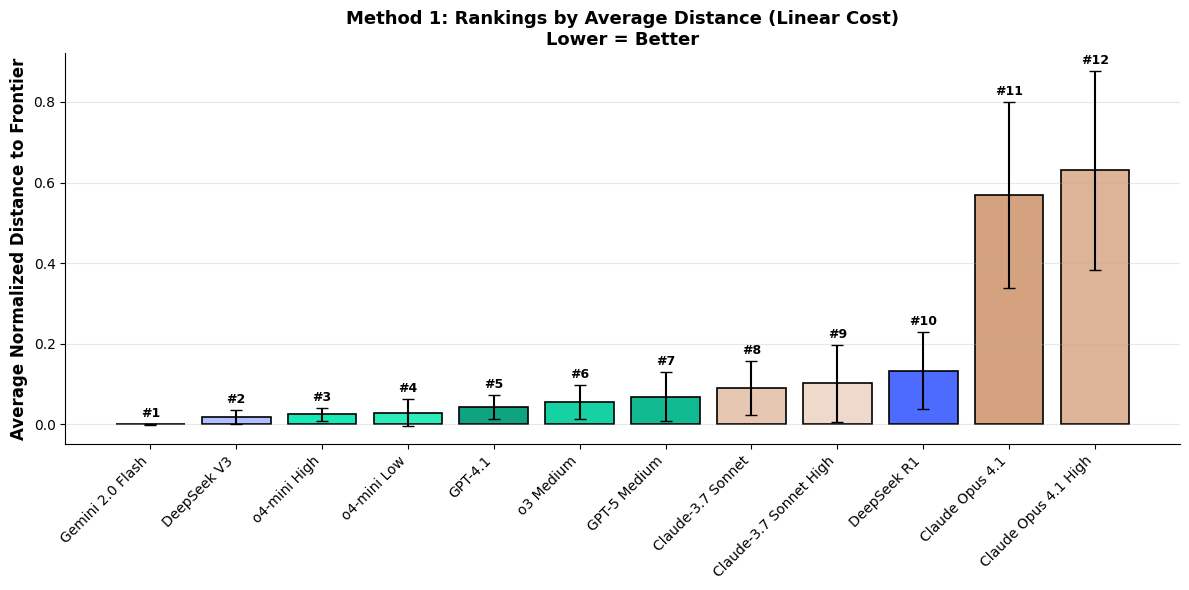

In [10]:
# Bar plot for Method 1 with confidence intervals
fig, ax = plt.subplots(figsize=(12, 6))

# Sort by average distance (lower is better)
plot_data = rankings_linear.sort_values('avg_distance', ascending=True)
shade_of = setup_colors(plot_data.index.tolist())

x_pos = np.arange(len(plot_data))
colors = [shade_of.get(model, '#777777') for model in plot_data.index]

# Use standard error as confidence interval (std / sqrt(n))
# For models with only 1 benchmark, std is NaN, so we use 0
n_benchmarks = plot_data['benchmarks_tested'].values
stderr = plot_data['std_distance'].fillna(0) / np.sqrt(n_benchmarks)

ax.bar(x_pos, plot_data['avg_distance'], 
       yerr=stderr * 1.96,  # 95% confidence interval
       color=colors, 
       edgecolor='black', 
       linewidth=1.2,
       capsize=4,
       error_kw={'linewidth': 1.5, 'ecolor': 'black'})

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_data.index, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Average Normalized Distance to Frontier', fontsize=12, fontweight='bold')
ax.set_title('Method 1: Rankings by Average Distance (Linear Cost)\nLower = Better', 
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
sns.despine(ax=ax, top=True, right=True)

# Add rank numbers on bars
for i, (idx, row) in enumerate(plot_data.iterrows()):
    ax.text(i, row['avg_distance'] + stderr.iloc[i] * 1.96 + 0.01, 
            f"#{i+1}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Method 2: Average Unweighted Normalized Distance (Log Cost)

In [16]:
# Method 2: Average Unweighted Normalized Distance (Log Cost)
distance_df_log = compute_frontier_distances(model_df, use_log_cost=True)

rankings_log = distance_df_log.groupby('model').agg({
    'normalized_distance': ['mean', 'std'],
    'is_on_pareto': 'sum',
    'benchmark_name': 'count'
}).round(4)

rankings_log.columns = ['avg_distance', 'std_distance', 'pareto_appearances', 'benchmarks_tested']
rankings_log = rankings_log.sort_values('avg_distance')

print("METHOD 2: Average Unweighted Normalized Distance (Log Cost)")
print("="*80)
print("\nUses log₁₀(cost) - treats cost multiplicatively (10× increase is same")
print("whether $1→$10 or $100→$1000)\n")
print(rankings_log[['avg_distance', 'std_distance', 'pareto_appearances']])

METHOD 2: Average Unweighted Normalized Distance (Log Cost)

Uses log₁₀(cost) - treats cost multiplicatively (10× increase is same
whether $1→$10 or $100→$1000)

                        avg_distance  std_distance  pareto_appearances
model                                                                 
Gemini 2.0 Flash              0.0741        0.0846                   3
GPT-5 Medium                  0.1170        0.1096                   2
o3 Medium                     0.1210        0.1350                   3
o4-mini Low                   0.1307        0.1353                   2
GPT-4.1                       0.1469        0.1717                   1
o4-mini High                  0.1566        0.1243                   0
Claude-3.7 Sonnet High        0.2103        0.1718                   1
DeepSeek V3                   0.2347        0.1858                   0
Claude-3.7 Sonnet             0.2621        0.2103                   0
Claude Opus 4.1               0.4012        0.3307       

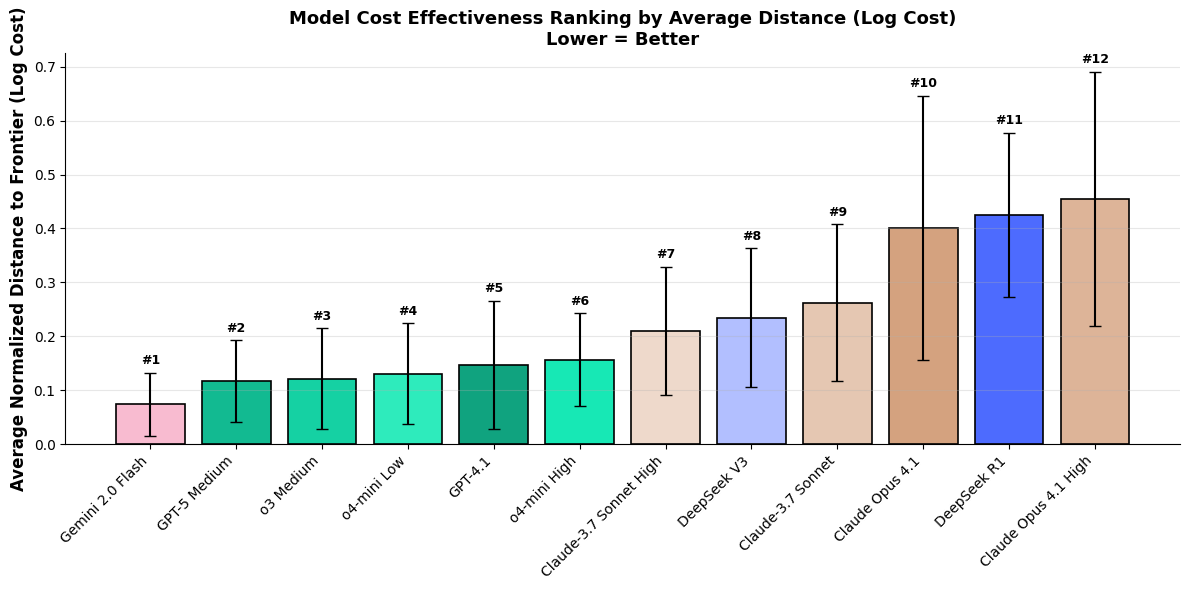

In [17]:
# Bar plot for Method 2 with confidence intervals
fig, ax = plt.subplots(figsize=(12, 6))

# Sort by average distance (lower is better)
plot_data = rankings_log.sort_values('avg_distance', ascending=True)
shade_of = setup_colors(plot_data.index.tolist())

x_pos = np.arange(len(plot_data))
colors = [shade_of.get(model, '#777777') for model in plot_data.index]

# Use standard error as confidence interval
n_benchmarks = plot_data['benchmarks_tested'].values
stderr = plot_data['std_distance'].fillna(0) / np.sqrt(n_benchmarks)

ax.bar(x_pos, plot_data['avg_distance'], 
       yerr=stderr * 1.96,  # 95% confidence interval
       color=colors, 
       edgecolor='black', 
       linewidth=1.2,
       capsize=4,
       error_kw={'linewidth': 1.5, 'ecolor': 'black'})

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_data.index, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Average Normalized Distance to Frontier (Log Cost)', fontsize=12, fontweight='bold')
ax.set_title('Model Cost Effectiveness Ranking by Average Distance (Log Cost)\nLower = Better', 
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
sns.despine(ax=ax, top=True, right=True)

# Add rank numbers on bars
for i, (idx, row) in enumerate(plot_data.iterrows()):
    ax.text(i, row['avg_distance'] + stderr.iloc[i] * 1.96 + 0.01, 
            f"#{i+1}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Method 3: Average Accuracy-Weighted Distance

In [17]:
# Method 3: Average Accuracy-Weighted Distance
weighted_df = compute_accuracy_weighted_distances(benchmark_df, weighting_method='utility_score', use_log_cost=False)

rankings_weighted = weighted_df.groupby('model').agg({
    'weighted_distance': 'mean',
    'is_on_pareto': 'sum',
    'benchmark_name': 'count'
}).round(4)

rankings_weighted.columns = ['avg_utility_score', 'pareto_appearances', 'benchmarks_tested']
rankings_weighted = rankings_weighted.sort_values('avg_utility_score', ascending=False)
rankings_weighted['rank'] = range(1, len(rankings_weighted) + 1)

print("METHOD 3: Average Accuracy-Weighted Distance")
print("="*80)
print("\nUtility Score = accuracy / (1 + distance)")
print("Higher is better. Balances accuracy and distance to frontier.\n")
print("\nProblem: Cheap models ranked at bottom even if always on frontier.\n")
print(rankings_weighted[['rank', 'avg_utility_score', 'pareto_appearances']])

METHOD 3: Average Accuracy-Weighted Distance

Utility Score = accuracy / (1 + distance)
Higher is better. Balances accuracy and distance to frontier.


Problem: Cheap models ranked at bottom even if always on frontier.

                        rank  avg_utility_score  pareto_appearances
model                                                              
Claude Sonnet 4            1             0.3833                   1
Claude Sonnet 4 High       2             0.3572                   0
GPT-5 Medium               3             0.3413                   4
o4-mini High               4             0.2912                   3
Claude-3.7 Sonnet          5             0.2837                   2
Claude-3.7 Sonnet High     6             0.2775                   1
o3 Medium                  7             0.2771                   3
GPT-4.1                    8             0.2571                   2
o4-mini Low                9             0.2513                   4
Claude Opus 4.1           10    

In [ ]:
# Bar plot for Method 3 with confidence intervals
# For utility score, we need to compute std across benchmarks
weighted_stats = weighted_df.groupby('model').agg({
    'weighted_distance': ['mean', 'std'],
    'is_on_pareto': 'sum',
    'benchmark_name': 'count'
}).round(4)

weighted_stats.columns = ['avg_utility', 'std_utility', 'pareto_appearances', 'benchmarks_tested']

fig, ax = plt.subplots(figsize=(12, 6))

# Sort by average utility (higher is better)
plot_data = weighted_stats.sort_values('avg_utility', ascending=False)
shade_of = setup_colors(plot_data.index.tolist())

x_pos = np.arange(len(plot_data))
colors = [shade_of.get(model, '#777777') for model in plot_data.index]

# Use standard error as confidence interval
n_benchmarks = plot_data['benchmarks_tested'].values
stderr = plot_data['std_utility'].fillna(0) / np.sqrt(n_benchmarks)

ax.bar(x_pos, plot_data['avg_utility'], 
       yerr=stderr * 1.96,  # 95% confidence interval
       color=colors, 
       edgecolor='black', 
       linewidth=1.2,
       capsize=4,
       error_kw={'linewidth': 1.5, 'ecolor': 'black'})

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_data.index, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Average Utility Score (accuracy / (1 + distance))', fontsize=12, fontweight='bold')
ax.set_title('Method 3: Rankings by Accuracy-Weighted Utility\nHigher = Better', 
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
sns.despine(ax=ax, top=True, right=True)

# Add rank numbers on bars
for i, (idx, row) in enumerate(plot_data.iterrows()):
    ax.text(i, row['avg_utility'] + stderr.iloc[i] * 1.96 + 0.01, 
            f"#{i+1}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Method 4: Global Pareto Frontier (Average Cost & Accuracy)

In [18]:
# Method 4: Global Pareto Frontier (Average Cost & Accuracy)
global_avg_df = compute_global_average_metrics(benchmark_df)

# Compute global Pareto frontier
avg_costs = global_avg_df['avg_cost'].to_numpy()
avg_accs = global_avg_df['avg_accuracy'].to_numpy()
global_pareto_frontier = compute_pareto_frontier_with_origin(avg_costs, avg_accs)

# Identify which models are on the global frontier
costs_with_origin = np.concatenate([[0], avg_costs])
accs_with_origin = np.concatenate([[0], avg_accs])
global_p_idx = _pareto_indices(costs_with_origin, accs_with_origin)
pareto_indices = [idx - 1 for idx in global_p_idx if idx > 0]
global_avg_df['is_on_global_pareto'] = False
global_avg_df.loc[global_avg_df.index[pareto_indices], 'is_on_global_pareto'] = True

# Sort by average cost
global_rankings = global_avg_df.sort_values('avg_cost')[['avg_cost', 'avg_accuracy', 'is_on_global_pareto', 'num_benchmarks']]

print("METHOD 4: Global Pareto Frontier")
print("="*80)
print("\nCompute average cost and accuracy across all benchmarks per model,")
print("then compute Pareto frontier on these global averages.\n")
print(f"{'Model':<30} {'Avg Cost':<12} {'Avg Acc':<10} {'On Frontier':<12} {'Benchmarks':<10}")
print("-"*80)
for model, row in global_rankings.iterrows():
    pareto_mark = "✓" if row['is_on_global_pareto'] else ""
    print(f"{model:<30} ${row['avg_cost']:<11.2f} {row['avg_accuracy']*100:<9.1f}% {pareto_mark:<12} {int(row['num_benchmarks']):<10}")

METHOD 4: Global Pareto Frontier

Compute average cost and accuracy across all benchmarks per model,
then compute Pareto frontier on these global averages.

Model                          Avg Cost     Avg Acc    On Frontier  Benchmarks
--------------------------------------------------------------------------------
10                             $6.35        14.9     % ✓            9         
7                              $46.11       18.4     %              9         
13                             $62.53       25.8     % ✓            9         
12                             $88.81       30.1     % ✓            9         
8                              $89.49       26.5     %              9         
6                              $111.93      15.6     %              9         
9                              $147.01      35.5     % ✓            9         
11                             $147.77      29.0     %              9         
5                              $166.14      28.8   

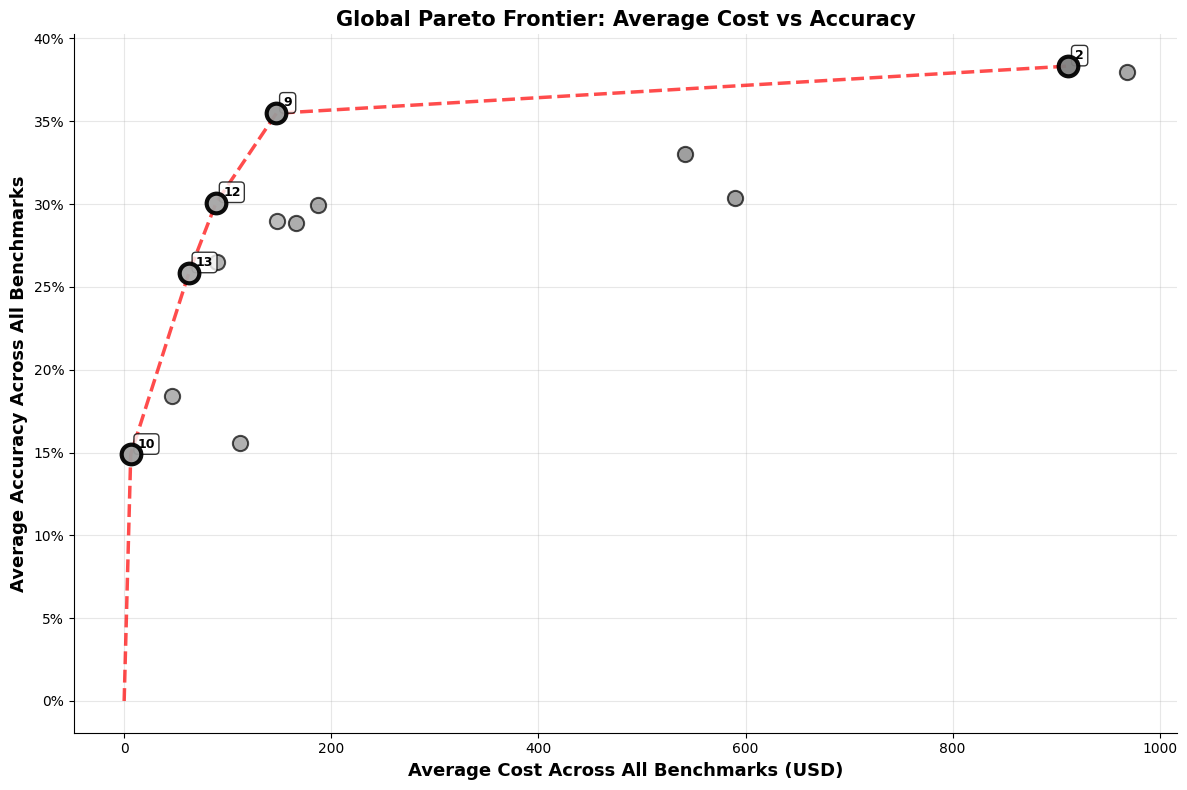

In [19]:
# Visualization: Global Pareto Frontier
fig, ax = plt.subplots(figsize=(12, 8))

shade_of = setup_colors(global_avg_df.index.tolist())

for model, row in global_avg_df.iterrows():
    is_pareto = row['is_on_global_pareto']
    ax.scatter(
        row['avg_cost'], row['avg_accuracy'],
        s=200 if is_pareto else 120,
        color=shade_of.get(model, '#777777'),
        edgecolor='black',
        linewidth=3.0 if is_pareto else 1.5,
        alpha=0.95 if is_pareto else 0.7,
        zorder=5 if is_pareto else 3
    )

# Plot Pareto frontier line
if len(global_pareto_frontier) >= 2:
    ax.plot(global_pareto_frontier[:, 0], global_pareto_frontier[:, 1],
            linestyle='--', linewidth=2.5, color='red', alpha=0.7, zorder=2)

# Annotate Pareto models
pareto_models = global_avg_df[global_avg_df['is_on_global_pareto']].sort_values('avg_cost')
for model, row in pareto_models.iterrows():
    ax.annotate(model, xy=(row['avg_cost'], row['avg_accuracy']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.8))

ax.set_xlabel('Average Cost Across All Benchmarks (USD)', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Accuracy Across All Benchmarks', fontsize=13, fontweight='bold')
ax.set_title('Global Pareto Frontier: Average Cost vs Accuracy', fontsize=15, fontweight='bold')
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.grid(True, alpha=0.3)
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()